<a href="https://colab.research.google.com/github/AqsaAamena/Basic-Python-Projects/blob/main/Assignment_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1. Load the Heart Disease dataset using pandas and display the first 10 rows.
Also check the shape and basic information (info()) of the dataset.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
data=pd.read_csv('heart.csv')
#displays the first 10 rows of heart disease dataset
data.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [15]:
#shape of dataset
print("Shape of dataset:-",data.shape)
#basic information of dataset
print("\n-----------Basic information of heart disease dataset----------")
data.info()

Shape of dataset:- (918, 12)

-----------Basic information of heart disease dataset----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Q2. Check for missing values in the dataset. Show the count of null values for
each column.

In [18]:
# Check for missing values in each column
missing_values = data.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


Q3. Check for duplicate rows in the dataset. If any duplicates are found, remove
them and print the new shape of the dataset.

In [21]:
# Check for duplicate rows
num_duplicates = data.duplicated().sum()
print("Number of duplicate rows in dataset:", num_duplicates)
# If duplicates exist, drop them
if num_duplicates > 0:
    data = data.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicates found.")
# Print the final shape of the dataset
print("Final shape of dataset:", data.shape)

Number of duplicate rows in dataset: 0
No duplicates found.
Final shape of dataset: (918, 12)


Q4. Identify unrealistic/invalid values:
Count how many rows have Cholesterol = 0.
Count how many rows have RestingBP = 0.
Print both counts.

In [30]:
#count rows of Cholesterol = 0
count_cholesterol=(data['Cholesterol']==0).sum()
print("Count of rows with Cholesterol=0:",count_cholesterol)

#count rows of RestingBP = 0
count_restingbp=(data["RestingBP"]==0).sum()
print("Count of rows with RestingBP=0:",count_restingbp)

Count of rows with Cholesterol=0: 172
Count of rows with RestingBP=0: 1


Q5. Clean the invalid values:
Replace Cholesterol = 0 with the mean cholesterol value (excluding zeros).
Replace RestingBP = 0 with the mean resting blood pressure value (excluding
zeros).
Round both columns to 2 decimal places.
Print the statistical summary (describe()) of these two columns before and after
cleaning.

In [43]:
#Statistical summary of cholesterol and RestingBP using describe()
print("----Statistical Summary before cleaning----")
print(data[["Cholesterol","RestingBP"]].describe())
#calculate mean of both columns excluding zero
mean_cholesterol=data[data["Cholesterol"]!=0]["Cholesterol"].mean()
mean_restingbp=data[data["RestingBP"]!=0]["RestingBP"].mean()
#replace 0 with mean of the columns
data["Cholesterol"]=data["Cholesterol"].replace(0,mean_cholesterol)
data["RestingBP"]=data["RestingBP"].replace(0,mean_restingbp)
#round both columns to 2 decimal places
data["Cholesterol"]=data["Cholesterol"].round(2)
data["RestingBP"]=data["RestingBP"].round(2)
print("\n----Statistical Summary after cleaning----")
print(data[["Cholesterol","RestingBP"]].describe())

----Statistical Summary before cleaning----
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.635389  132.540894
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.635389  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

----Statistical Summary after cleaning----
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


Q6. Create a function to plot histograms for the following numerical columns:
Age
RestingBP
Cholesterol
MaxHR
Plot all four histograms in one figure using subplots (2x2 layout). Use this function
to visualize the data after cleaning.

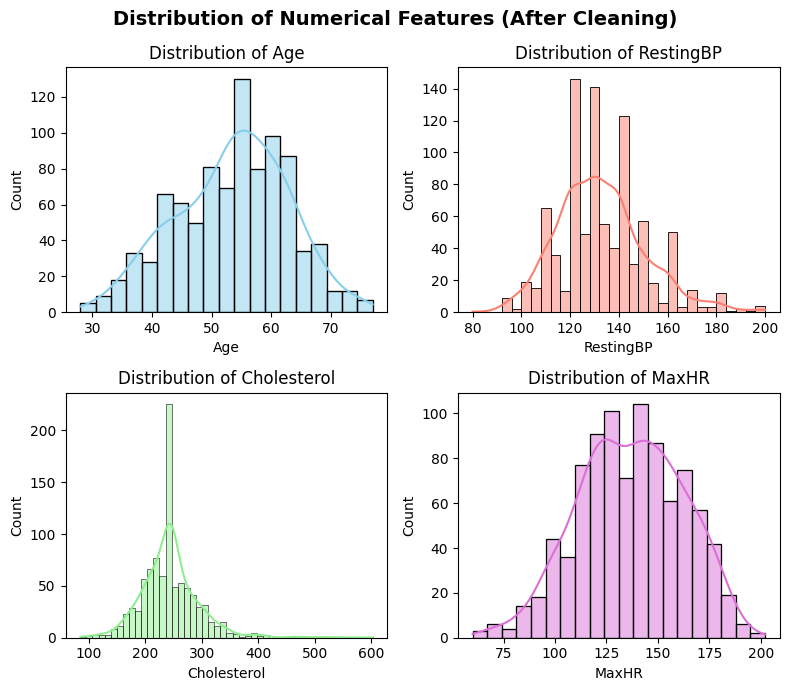

In [62]:
def plot_histograms(data):
    # Set up the 2x2 subplot figure structure
    fig, axes = plt.subplots(2, 2, figsize=(8, 7))
    fig.suptitle('Distribution of Numerical Features (After Cleaning)', fontsize=14, fontweight='bold')
    # List of columns to plot
    columns = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']
    colors = ['skyblue', 'salmon', 'lightgreen', 'orchid']
    #Flatten the 2x2 axes array to easily loop through it
    axes = axes.flatten()
    # Loop to plot each histogram
    for i, col in enumerate(columns):
        sns.histplot(data=data, x=col, kde=True, ax=axes[i], color=colors[i])
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
    plt.tight_layout()
    plt.show()
# Call the function to visualize your cleaned data
plot_histograms(data)

Q7. Identify and print numerical columns and categorical columns separately.

In [63]:
#Identify numerical columns
numerical_columns=data.select_dtypes(include=['int64','float64']).columns
print("Numerical columns:-",numerical_columns)
#Identify categorical columns
categorical_columns=data.select_dtypes(include=['object']).columns
print("Categorical columns:-",categorical_columns)

Numerical columns:- Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')
Categorical columns:- Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


Q8. Perform One-Hot Encoding on all categorical columns using
pd.get_dummies().
Store the result in a new dataframe called df_encoded.
Print the shape and the first 5 rows of the encoded dataframe.

In [68]:
categorical_columns=data.select_dtypes(include=['object']).columns
df_encoded=pd.get_dummies(data,columns=categorical_columns)
print("Shape of encoded dataframe:-",df_encoded.shape)
print("\nFirst 5 rows of encoded dataframe:-")
print(df_encoded.head())

Shape of encoded dataframe:- (918, 21)

First 5 rows of encoded dataframe:-
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             Fa

Q9. After cleaning and encoding:
Print the final shape of df_encoded.
Show the list of all column names in the final dataframe.

In [70]:
# Print the final shape of the encoded dataframe
print("Final shape of df_encoded:", df_encoded.shape)

# Show the list of all column names
print("\nList of all column names:")
print(df_encoded.columns)

Final shape of df_encoded: (918, 21)

List of all column names:
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


Q10. (Summary)
Write a short summary (in comments or markdown) covering:
1. What invalid values did you find and how did you fix them?
2. Why is it important to handle invalid values like Cholesterol = 0?
3. What is the purpose of One-Hot Encoding?
4. Any other observations from the cleaning process.

In [ ]:
# =================================================================
# Q10. SUMMARY & REFLECTIONS
# =================================================================

# 1.
# - Cholesterol (172 zeros) and RestingBP (1 zero) were impossible.
# - Replaced all zeros with the column averages and rounded to 2 decimals.

# 2.
# - Living people cannot have 0 blood pressure or cholesterol.
#   Leaving zeros breaks the math and ruins model accuracy.

# 3.
# - ML models only understand numbers, not text like "Male" or "Normal".
# - It turns text into columns of 1s (Yes) and 0s (No) for the computer.

# 4. Key Observations:
# - "Zero missing values" can hide fake data placeholders like 0.
# - Keeping rows by using the mean is better than deleting data.
# - One-hot encoding grew our dataset from 12 to 21 columns.